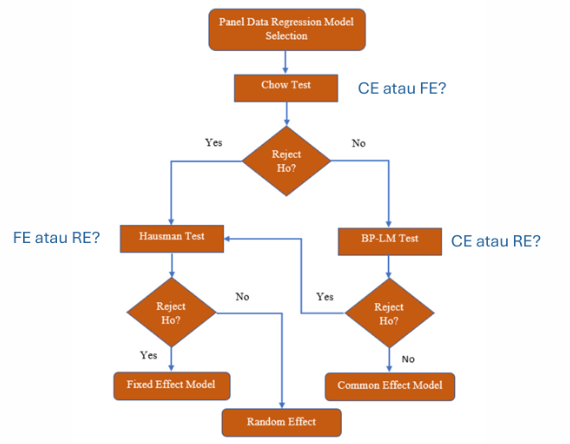

# Import Library

In [ ]:
import pandas as pd
import warnings
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from linearmodels.panel import PanelOLS, RandomEffects
from scipy.stats import chi2
from statsmodels.tools.tools import add_constant
warnings.filterwarnings('ignore')


# Prepocessing Data

In [2]:
# Baca data dari file CSV
pdrb_df = pd.read_csv("PDRB.csv")
ump_df = pd.read_csv("UMP.csv")
ipm_df = pd.read_csv("IPM.csv")
krt_df = pd.read_csv("Rata-Rata Konsumsi Rumah Tangga.csv")
investasi_df = pd.read_csv("Investasi.csv")

# Ubah data UMP menjadi format long
ump_long_df = ump_df.melt(id_vars=["Provinsi"], 
                          var_name="Tahun", 
                          value_name="UMP")

# Ubah data IPM menjadi format long
ipm_long_df = ipm_df.melt(id_vars=["Provinsi"], 
                          var_name="Tahun", 
                          value_name="IPM")

# Ubah data investasi menjadi format long
investasi_long_df = investasi_df.melt(id_vars=["Provinsi"], 
                                      var_name="Tahun", 
                                      value_name="Investasi")

# Ubah data KRT menjadi format long
krt_long_df = krt_df.melt(id_vars=["Provinsi"], 
                          var_name="Tahun", 
                          value_name="KRT")

# Ubah nama kolom 'Provinsi' di semua dataframe agar konsisten
pdrb_df['Provinsi'] = pdrb_df['Provinsi'].str.title()
ump_long_df['Provinsi'] = ump_long_df['Provinsi'].str.title()
ipm_long_df['Provinsi'] = ipm_long_df['Provinsi'].str.title()
investasi_long_df['Provinsi'] = investasi_long_df['Provinsi'].str.title()
krt_long_df['Provinsi'] = krt_long_df['Provinsi'].str.title()

# Pastikan kolom tahun adalah integer untuk penyelarasan
pdrb_df['Tahun'] = pdrb_df['Tahun'].astype(int)
ump_long_df['Tahun'] = ump_long_df['Tahun'].astype(int)
ipm_long_df['Tahun'] = ipm_long_df['Tahun'].astype(int)
investasi_long_df['Tahun'] = investasi_long_df['Tahun'].astype(int)
krt_long_df['Tahun'] = krt_long_df['Tahun'].astype(int)

# Gabungkan semua data berdasarkan kolom 'Provinsi' dan 'Tahun'
merged_df = pd.merge(pdrb_df, ump_long_df, on=["Provinsi", "Tahun"], how="left")
merged_df = pd.merge(merged_df, ipm_long_df, on=["Provinsi", "Tahun"], how="left")
merged_df = pd.merge(merged_df, investasi_long_df, on=["Provinsi", "Tahun"], how="left")
merged_df = pd.merge(merged_df, krt_long_df, on=["Provinsi", "Tahun"], how="left")

# Tampilkan hasil
print(merged_df)

# Simpan hasil ke file CSV
merged_df.to_csv("data.csv", index=False)

             Provinsi  Tahun       PDRB           UMP    IPM Investasi  \
0                Aceh   2019   30879.06  2,916,810.00  71.90    3606.9   
1      Sumatera Utara   2019   54620.40  2,303,403.43  71.74     19749   
2      Sumatera Barat   2019   44885.51  2,289,220.00  72.39    3026.6   
3                Riau   2019  111227.00  2,662,025.63  73.00   26292.2   
4               Jambi   2019   60828.86  2,423,889.16  71.26    4437.4   
..                ...    ...        ...           ...    ...       ...   
185  Papua Barat Daya   2023   58450.13           NaN    NaN    1708.7   
186             Papua   2023   78061.39  3,864,696.00  62.25    1174.1   
187     Papua Selatan   2023   58680.24           NaN    NaN     152.5   
188      Papua Tengah   2023  103503.90           NaN    NaN     458.8   
189  Papua Pegunungan   2023   16869.97           NaN    NaN     121.8   

           KRT  
0    4292685.0  
1    4498122.0  
2    4955589.0  
3    5043397.0  
4    4180221.0  
..       

In [3]:
# Membaca data
data = pd.read_csv("data.csv")

# Bersihkan kolom UMP
data['UMP'] = data['UMP'].str.replace(',', '').astype(float)

# Jika kolom 'Provinsi' memiliki nama lain, misalnya 'Province' atau variasi lainnya, ubah sesuai dengan nama yang benar
# Ganti 'Provinsi' di sini jika perlu berdasarkan output kolom
provinsi_dihapus = ['Papua Barat Daya', 'Papua Selatan', 'Papua Tengah', 'Papua Pegunungan']
if 'Provinsi' in data.columns:
    data = data[~data['Provinsi'].isin(provinsi_dihapus)]
else:
    print("Kolom 'Provinsi' tidak ditemukan. Silakan cek nama kolom yang benar.")

# Tampilkan data untuk verifikasi
print(data.head())
data.to_csv('dataset.csv', index=False)

         Provinsi  Tahun       PDRB         UMP    IPM Investasi        KRT
0            Aceh   2019   30879.06  2916810.00  71.90    3606.9  4292685.0
1  Sumatera Utara   2019   54620.40  2303403.43  71.74     19749  4498122.0
2  Sumatera Barat   2019   44885.51  2289220.00  72.39    3026.6  4955589.0
3            Riau   2019  111227.00  2662025.63  73.00   26292.2  5043397.0
4           Jambi   2019   60828.86  2423889.16  71.26    4437.4  4180221.0


# Uji Heteroskedastisitas

In [4]:
# Baca dataset
dataset = pd.read_csv("dataset.csv")

# Definisikan variabel dependen dan independen
y = dataset['Investasi']  # Variabel dependen
X = dataset.drop(columns=['Provinsi', 'Tahun', 'Investasi'])  # Variabel independen

# Tambahkan konstanta pada variabel independen
X = sm.add_constant(X)

# Model Regresi OLS tanpa transformasi pada variabel dependen
model = sm.OLS(y, X).fit()

# Uji Heteroskedastisitas (Breusch-Pagan Test)
residuals = model.resid
bp_test = het_breuschpagan(residuals, X)

# Output hasil uji Breusch-Pagan dengan format yang lebih rapi
print("\nUji Heteroskedastisitas (Breusch-Pagan Test):")
print(f"LM Statistic: {bp_test[0]}")
print(f"LM-Test p-value: {bp_test[1]}")
print(f"F-Statistic: {bp_test[2]}")
print(f"F-Test p-value: {bp_test[3]}")

# Menentukan apakah ada heteroskedastisitas
if bp_test[1] < 0.05:
    print("Ada heteroskedastisitas dalam data.")
else:
    print("Tidak ada heteroskedastisitas dalam data.")


Uji Heteroskedastisitas (Breusch-Pagan Test):
LM Statistic: 40.657876416699125
LM-Test p-value: 3.163905833420841e-08
F-Statistic: 12.966675942263336
F-Test p-value: 3.3352912403124188e-09
Ada heteroskedastisitas dalam data.


In [5]:
# Tranformasi untuk mengatasi Heteroskedastisitas
# Transformasi logaritma pada variabel dependen (untuk mengurangi heteroskedastisitas)
y_transformed = np.log1p(y)  # log(1+x) untuk menghindari log(0)

# Model Regresi OLS dengan Data yang sudah ditransformasi
model = sm.OLS(y_transformed, X).fit()

# Uji Heteroskedastisitas (Breusch-Pagan Test)
residuals = model.resid
bp_test = het_breuschpagan(residuals, X)

# Output hasil uji Breusch-Pagan dengan format yang lebih rapi
print("\nUji Heteroskedastisitas (Breusch-Pagan Test):")
print(f"LM Statistic: {bp_test[0]}")
print(f"LM-Test p-value: {bp_test[1]}")
print(f"F-Statistic: {bp_test[2]}")
print(f"F-Test p-value: {bp_test[3]}")

# Menentukan apakah ada heteroskedastisitas
if bp_test[1] < 0.05:
    print("Ada heteroskedastisitas dalam data.")
else:
    print("Tidak ada heteroskedastisitas dalam data.")


Uji Heteroskedastisitas (Breusch-Pagan Test):
LM Statistic: 26.113569982783474
LM-Test p-value: 3.001900746864862e-05
F-Statistic: 7.48635407564792
F-Test p-value: 1.446960988790892e-05
Ada heteroskedastisitas dalam data.


In [6]:
# Transformasi logaritma pada variabel dependen dan independen
X_log = np.log1p(X)  # log(1+x) untuk menghindari log(0) pada variabel independen
y_log = np.log1p(y)  # log(1+x) untuk menghindari log(0) pada variabel dependen

# Tambahkan konstanta pada variabel independen
X_log = sm.add_constant(X_log)

# Model Regresi OLS dengan Data yang sudah ditransformasi
model = sm.OLS(y_log, X_log).fit()

# Uji Heteroskedastisitas (Breusch-Pagan Test)
residuals = model.resid
bp_test = het_breuschpagan(residuals, X_log)

# Output hasil uji Breusch-Pagan dengan format yang lebih rapi
print("\nUji Heteroskedastisitas (Breusch-Pagan Test):")
print(f"LM Statistic: {bp_test[0]}")
print(f"LM-Test p-value: {bp_test[1]}")
print(f"F-Statistic: {bp_test[2]}")
print(f"F-Test p-value: {bp_test[3]}")

# Menentukan apakah ada heteroskedastisitas
if bp_test[1] < 0.05:
    print("Ada heteroskedastisitas dalam data.")
else:
    print("Tidak ada heteroskedastisitas dalam data.")


Uji Heteroskedastisitas (Breusch-Pagan Test):
LM Statistic: 25.631922544203093
LM-Test p-value: 3.7538753408346044e-05
F-Statistic: 7.323757603353211
F-Test p-value: 1.8737144298612373e-05
Ada heteroskedastisitas dalam data.


# Regresi Data Panel

# Chow Test

In [7]:
# Membaca dataset
dataset = pd.read_csv('dataset.csv')

# Pastikan kolom 'Tahun' dalam format integer
dataset['Tahun'] = pd.to_numeric(dataset['Tahun'], errors='coerce')

# Pastikan 'Provinsi' adalah tipe string
dataset['Provinsi'] = dataset['Provinsi'].astype(str)

# Mengonversi data ke format panel dengan multi-indeks berdasarkan 'Provinsi' dan 'Tahun'
dataset = dataset.set_index(['Provinsi', 'Tahun'])

# 1. Uji Chow
# Membandingkan model Common Effect dan Fixed Effect
mod_common = PanelOLS.from_formula('Investasi ~ PDRB + UMP + IPM + KRT', data=dataset)
mod_fixed = PanelOLS.from_formula('Investasi ~ PDRB + UMP + IPM + KRT + EntityEffects', data=dataset)

# Estimasi model
res_common = mod_common.fit()
res_fixed = mod_fixed.fit()

# Statistik F untuk uji Chow
RSS_common = res_common.resids @ res_common.resids
RSS_fixed = res_fixed.resids @ res_fixed.resids
N = dataset.shape[0]  # Jumlah observasi
k = len(res_fixed.params)  # Jumlah parameter
df_numerator = dataset.index.levels[0].size - 1  # Jumlah entitas - 1
df_denominator = N - k - df_numerator  # Derajat bebas residual

F_stat = ((RSS_common - RSS_fixed) / df_numerator) / (RSS_fixed / df_denominator)
p_value_chow = 1 - chi2.cdf(F_stat, df_numerator)

print("Hasil Uji Chow:")
print("F-statistik:", F_stat)
print("p-value:", p_value_chow)
if p_value_chow < 0.05:
    print("Tolak H0: Lakukan Uji Hausman Test")
else:
    print("Terima H0: Lakukan Uji BP-LM Test")

Hasil Uji Chow:
F-statistik: 38.54667628597227
p-value: 0.23301655780116304
Terima H0: Lakukan Uji BP-LM Test


# BP-LM Test

In [8]:
# 2. Uji Breusch-Pagan Lagrange Multiplier (BP-LM)
# Dilakukan jika model Common Effect tidak ditolak
if p_value_chow >= 0.05:
    mod_re = RandomEffects.from_formula('Investasi ~ PDRB + UMP + IPM + KRT', data=dataset)
    res_re = mod_re.fit()

    # Statistik BP-LM
    N = dataset.shape[0]
    T = dataset.index.levels[1].size  # Jumlah periode waktu
    sigma_u2 = np.var(res_re.variance_decomposition['Effects'])
    sigma_e2 = np.var(res_re.resids)
    LM_stat = N * T / 2 * (sigma_u2 / sigma_e2)**2
    p_value_bplm = 1 - chi2.cdf(LM_stat, df=1)

    print("\nHasil Uji BP-LM:")
    print("LM-statistik:", LM_stat)
    print("p-value:", p_value_bplm)
    if p_value_bplm < 0.05:
        print("Tolak H0: Lakukan Uji Hausman Test")
    else:
        print("Terima H0: Gunakan model Common Effect.")


Hasil Uji BP-LM:
LM-statistik: 0.0
p-value: 1.0
Terima H0: Gunakan model Common Effect.


# Hausman Test

In [9]:
# # 3. Uji Hausman
# # Dilakukan jika Fixed Effect atau Random Effect dipilih
# if p_value_chow < 0.05 or (p_value_chow >= 0.05 and p_value_bplm < 0.05):
#     # Estimasi model Fixed Effect dan Random Effect
#     res_fixed = mod_fixed.fit()
#     res_re = mod_re.fit()

#     # Koefisien model
#     b_fixed = res_fixed.params
#     b_random = res_re.params

#     # Matriks kovarians
#     cov_fixed = res_fixed.cov
#     cov_random = res_re.cov

#     # Menghitung statistik Hausman
#     diff = b_fixed - b_random
#     try:
#         cov_diff_inv = np.linalg.inv(cov_fixed - cov_random)
#     except np.linalg.LinAlgError:
#         print("\nMatriks kovarians tidak dapat diinversikan. Coba periksa data atau variabel.")
#         exit()

#     stat_hausman = np.dot(np.dot(diff.T, cov_diff_inv), diff)
#     df_hausman = len(b_fixed)
#     p_value_hausman = 1 - chi2.cdf(stat_hausman, df_hausman)

#     print("\nHasil Uji Hausman:")
#     print("Hausman Test Statistic:", stat_hausman)
#     print("p-value:", p_value_hausman)
#     if p_value_hausman < 0.05:
#         print("Tolak H0: Gunakan model Fixed Effect.")
#     else:
#         print("Terima H0: Gunakan model Random Effect.")

In [10]:
# 4. Menampilkan Summary Model
# Menampilkan Summary Model Common Effect
print("\nSummary Model Common Effect:")
print(res_common.summary)

# Coba Bandingankan dengan Summary Model Fixed Effect
print("\nSummary Model Fixed Effect:")
print(res_fixed.summary)


Summary Model Common Effect:
                          PanelOLS Estimation Summary                           
Dep. Variable:              Investasi   R-squared:                        0.5952
Estimator:                   PanelOLS   R-squared (Between):              0.6261
No. Observations:                 170   R-squared (Within):               0.1308
Date:                Fri, Nov 29 2024   R-squared (Overall):              0.5952
Time:                        20:32:07   Log-likelihood                   -1878.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      61.013
Entities:                          34   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(4,166)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             61.01

# Menangani Heteroskedastisitas dengan WLS

In [11]:
# 5. Menangani Heteroskedastisitas dengan WLS
# Menggunakan residual dari model common effect
residuals = res_common.resids  # Menggunakan residual dari model common effect

# Hitung bobot berdasarkan residual
weights = 1 / (residuals**2)

# Fit model WLS dengan bobot
wls_model = sm.WLS(dataset['Investasi'], add_constant(dataset[['PDRB', 'UMP', 'IPM', 'KRT']]), weights=weights).fit()

# Menampilkan hasil WLS
print("\nHasil Regresi WLS:")
print(wls_model.summary())



Hasil Regresi WLS:
                            WLS Regression Results                            
Dep. Variable:              Investasi   R-squared:                       0.995
Model:                            WLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     8940.
Date:                Fri, 29 Nov 2024   Prob (F-statistic):          1.10e-191
Time:                        20:32:07   Log-Likelihood:                -1722.9
No. Observations:                 170   AIC:                             3456.
Df Residuals:                     165   BIC:                             3472.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2083.4845   2381.727